ЗАГРУЗКА ДАННЫХ
Загружено 541909 строк
Колонки: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

ШАГ 1: ПРЕДОБРАБОТКА ДАННЫХ
После очистки: 397884 строк
Уникальных клиентов: 4,338

ШАГ 2: РАСЧЁТ RFM-МЕТРИК
Дата анализа: 2011-12-10
RFM-таблица: 4,338 клиентов
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40

ШАГ 3: ШКАЛИРОВАНИЕ RFM

Распределение баллов:

Recency (R):
R_score
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64

Frequency (F):
F_score
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64

Monetary (M):
M_score
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64

ШАГ 4: СЕГМЕНТАЦИЯ КЛИЕНТОВ
СЕГМЕНТАЦИЯ КЛИЕНТОВ:
           Customers      Revenue  Customer_Pct  Rev

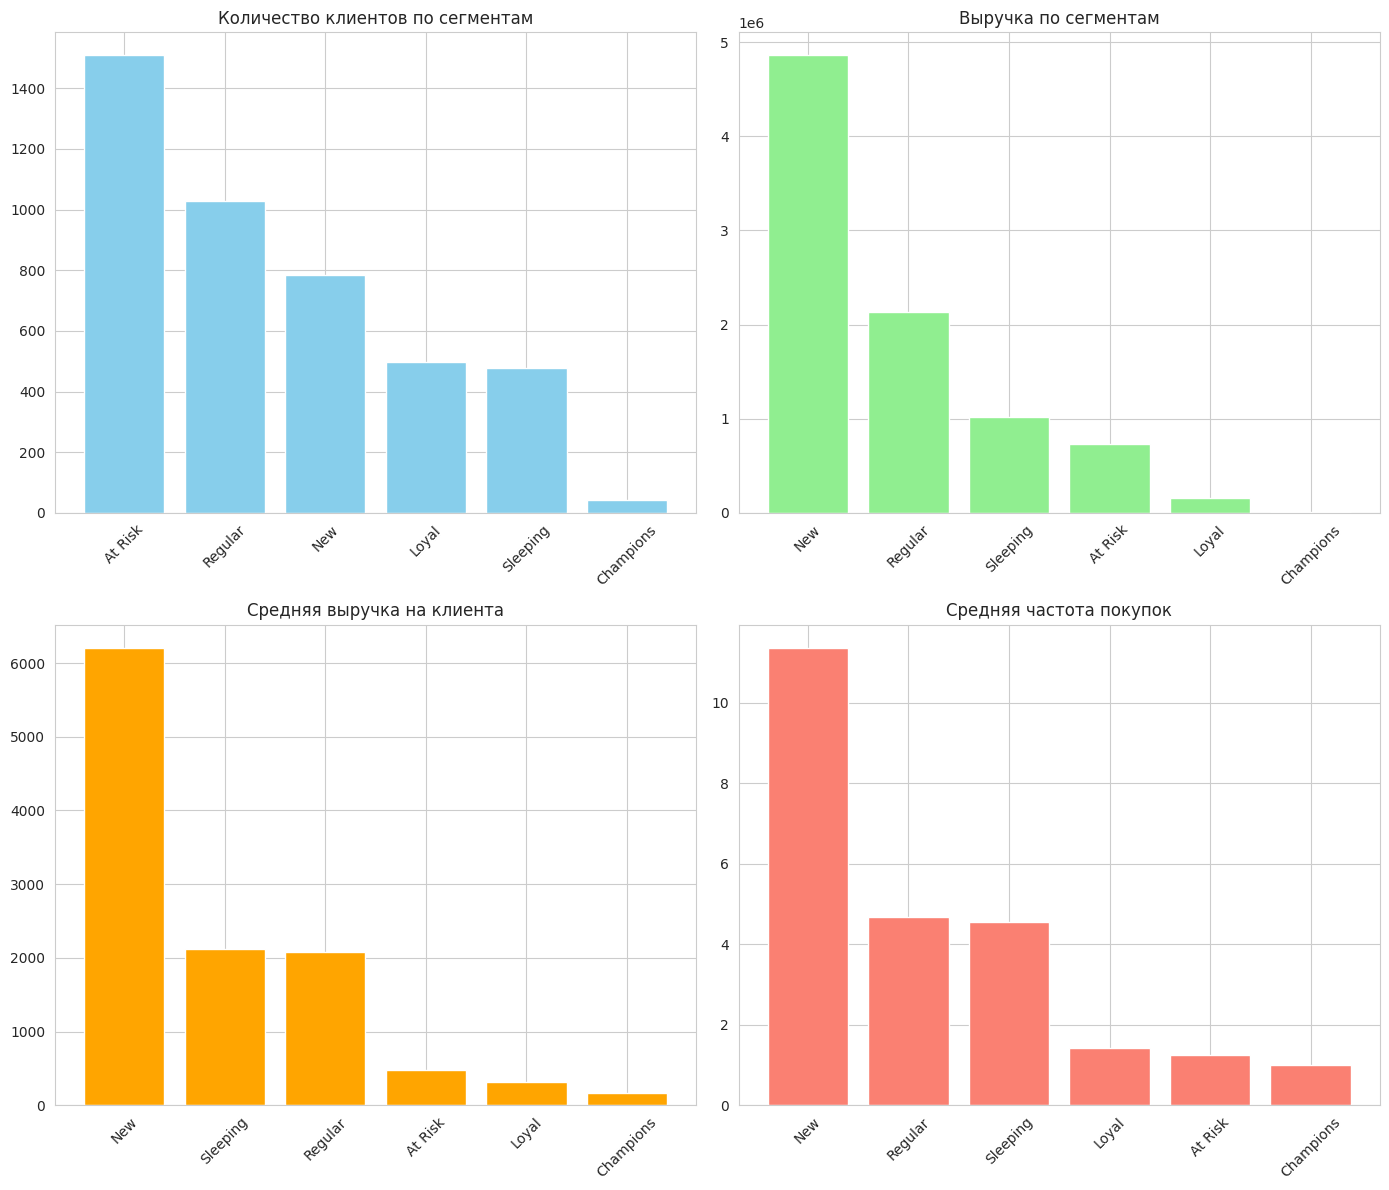


ИТОГОВЫЕ ВЫВОДЫ ПО RFM-АНАЛИЗУ

🏆 ТОП-10 КЛИЕНТОВ ПО ВЫРУЧКЕ:
 CustomerID  Monetary  Frequency  Recency Segment
    14646.0 280206.02         73        2     New
    18102.0 259657.30         60        1     New
    17450.0 194550.79         46        8     New
    16446.0 168472.50          2        1 Regular
    14911.0 143825.06        201        1     New
    12415.0 124914.53         21       24 Regular
    14156.0 117379.63         55       10     New
    17511.0  91062.38         31        3     New
    16029.0  81024.84         63       39 Regular
    12346.0  77183.60          1      326 At Risk

📊 ИНСАЙТЫ:
• Сегмент 'Champions': 42 чел. (1.0%)
  Приносят 0.1% выручки
  Средний чек: $167.06

💡 РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:
  • Champions: VIP-программа, ранний доступ, персональный менеджер
  • Loyal: Накопительные скидки, реферальная программа
  • New: Приветственный бонус, welcome-серия
  • At Risk: Реактивация купонами, напоминания
  • Sleeping: Проверить сезонность
  • Regular:

In [2]:
# ====================================================
# ПРОЕКТ: RFM-АНАЛИЗ РОЗНИЧНЫХ ПРОДАЖ
# ====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("ЗАГРУЗКА ДАННЫХ")
print("="*60)

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

df = pd.read_excel('Online Retail.xlsx')

print(f"Загружено {len(df)} строк")
print(f"Колонки: {df.columns.tolist()}")

# ====================================================
# ШАГ 1: ПРЕДОБРАБОТКА ДАННЫХ
# ====================================================

print("\n" + "="*60)
print("ШАГ 1: ПРЕДОБРАБОТКА ДАННЫХ")
print("="*60)

df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"После очистки: {len(df_clean)} строк")
print(f"Уникальных клиентов: {df_clean['CustomerID'].nunique():,}")

# ====================================================
# ШАГ 2: РАСЧЁТ RFM-МЕТРИК
# ====================================================

print("\n" + "="*60)
print("ШАГ 2: РАСЧЁТ RFM-МЕТРИК")
print("="*60)

analysis_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Дата анализа: {analysis_date.date()}")

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"RFM-таблица: {len(rfm):,} клиентов")
print(rfm.head())

# ====================================================
# ШАГ 3: ШКАЛИРОВАНИЕ С ОБРАБОТКОЙ ОШИБОК
# ====================================================

print("\n" + "="*60)
print("ШАГ 3: ШКАЛИРОВАНИЕ RFM")
print("="*60)

def assign_scores(df, column, reverse=False):
    """
    Присваивает баллы от 1 до 4 на основе квантилей.
    reverse=True для Recency (меньше = лучше)
    """
    try:
        if reverse:
            # Для Recency: ранг по возрастанию, потом квантили
            ranked = df[column].rank(method='first')
            labels = [4, 3, 2, 1]
        else:
            # Для Frequency/Monetary: ранг по убыванию
            ranked = df[column].rank(method='first', ascending=False)
            labels = [1, 2, 3, 4]

        # Используем qcut с параметром duplicates='drop'
        scores = pd.qcut(ranked, q=4, labels=labels, duplicates='drop')

        # Если получилось меньше 4 категорий, добавляем недостающие вручную
        unique_scores = scores.nunique()
        if unique_scores < 4:
            print(f"  ⚠️ {column}: получено {unique_scores} категорий вместо 4")
            # Преобразуем ранги в процентили и делим вручную
            percentiles = ranked / ranked.max()
            scores = pd.cut(percentiles, bins=4, labels=[1,2,3,4] if not reverse else [4,3,2,1])

        return scores.astype(int)
    except Exception as e:
        print(f"  ⚠️ Ошибка для {column}: {e}")
        # Fallback: простое разбиение на 4 группы
        labels = [4,3,2,1] if reverse else [1,2,3,4]
        return pd.cut(df[column], bins=4, labels=labels).astype(int)

# Присваиваем баллы
rfm['R_score'] = assign_scores(rfm, 'Recency', reverse=True)
rfm['F_score'] = assign_scores(rfm, 'Frequency', reverse=False)
rfm['M_score'] = assign_scores(rfm, 'Monetary', reverse=False)

rfm['RFM_Code'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print("\nРаспределение баллов:")
print("\nRecency (R):")
print(rfm['R_score'].value_counts().sort_index())
print("\nFrequency (F):")
print(rfm['F_score'].value_counts().sort_index())
print("\nMonetary (M):")
print(rfm['M_score'].value_counts().sort_index())

# ====================================================
# ШАГ 4: СЕГМЕНТАЦИЯ КЛИЕНТОВ
# ====================================================

print("\n" + "="*60)
print("ШАГ 4: СЕГМЕНТАЦИЯ КЛИЕНТОВ")
print("="*60)

def get_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']

    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    if r >= 3 and f >= 3 and m >= 3 and (r,f,m) != (4,4,4):
        return 'Loyal'
    if r >= 4 and f <= 2 and m <= 2:
        return 'New'
    if r <= 2 and f >= 3:
        return 'At Risk'
    if r <= 2 and f <= 2 and m <= 2:
        return 'Sleeping'
    return 'Regular'

rfm['Segment'] = rfm.apply(get_segment, axis=1)

segment_stats = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Monetary': 'sum'
}).rename(columns={'CustomerID': 'Customers', 'Monetary': 'Revenue'})

segment_stats['Customer_Pct'] = (segment_stats['Customers'] / segment_stats['Customers'].sum() * 100).round(1)
segment_stats['Revenue_Pct'] = (segment_stats['Revenue'] / segment_stats['Revenue'].sum() * 100).round(1)
segment_stats = segment_stats.sort_values('Revenue', ascending=False)

print("СЕГМЕНТАЦИЯ КЛИЕНТОВ:")
print(segment_stats)

# ====================================================
# ШАГ 5: ВИЗУАЛИЗАЦИЯ
# ====================================================

print("\n" + "="*60)
print("ШАГ 5: ВИЗУАЛИЗАЦИЯ")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Количество клиентов
segment_counts = rfm['Segment'].value_counts()
axes[0,0].bar(segment_counts.index, segment_counts.values, color='skyblue')
axes[0,0].set_title('Количество клиентов по сегментам')
axes[0,0].tick_params(axis='x', rotation=45)

# Выручка
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[0,1].bar(segment_revenue.index, segment_revenue.values, color='lightgreen')
axes[0,1].set_title('Выручка по сегментам')
axes[0,1].tick_params(axis='x', rotation=45)

# Средний чек
segment_avg = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1,0].bar(segment_avg.index, segment_avg.values, color='orange')
axes[1,0].set_title('Средняя выручка на клиента')
axes[1,0].tick_params(axis='x', rotation=45)

# Средняя частота
segment_freq = rfm.groupby('Segment')['Frequency'].mean().sort_values(ascending=False)
axes[1,1].bar(segment_freq.index, segment_freq.values, color='salmon')
axes[1,1].set_title('Средняя частота покупок')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ====================================================
# ШАГ 6: ИТОГОВЫЕ ВЫВОДЫ
# ====================================================

print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО RFM-АНАЛИЗУ")
print("="*60)

# Топ-10 клиентов
top_customers = rfm.nlargest(10, 'Monetary')[['CustomerID', 'Monetary', 'Frequency', 'Recency', 'Segment']]
print("\n🏆 ТОП-10 КЛИЕНТОВ ПО ВЫРУЧКЕ:")
print(top_customers.to_string(index=False))

# Ключевые инсайты
total_revenue = rfm['Monetary'].sum()
total_customers = len(rfm)

champions = rfm[rfm['Segment'] == 'Champions']
if len(champions) > 0:
    print(f"\n📊 ИНСАЙТЫ:")
    print(f"• Сегмент 'Champions': {len(champions)} чел. ({len(champions)/total_customers*100:.1f}%)")
    print(f"  Приносят {champions['Monetary'].sum()/total_revenue*100:.1f}% выручки")
    print(f"  Средний чек: ${champions['Monetary'].mean():.2f}")

print("\n💡 РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:")
recommendations = {
    'Champions': 'VIP-программа, ранний доступ, персональный менеджер',
    'Loyal': 'Накопительные скидки, реферальная программа',
    'New': 'Приветственный бонус, welcome-серия',
    'At Risk': 'Реактивация купонами, напоминания',
    'Sleeping': 'Проверить сезонность',
    'Regular': 'Стандартные коммуникации'
}

for seg in recommendations:
    if seg in segment_stats.index:
        print(f"  • {seg}: {recommendations[seg]}")

print("\n" + "="*60)
print("ПРОЕКТ ЗАВЕРШЁН")
print("="*60)